In [1]:
using LinearAlgebra
using Plots
using Statistics
using DelimitedFiles

# Projeto 2 - Jacobi e Gauss-Seidel

Modelo de entrega.

Respeite as divisões em Markdown para facilitar a navegação no relatório.

## Questão 1a: Implementação

Implemente os métodos de Jacobi e Gauss-Seidel para resolver o sistema linear $Ax = b$.

In [2]:
#Função que retorna o módulo da diferença entre as normas dos nossos vetores, para conseguimos dimensionar o erro da nossa solução
get_erro(x_real, x_aprox) = abs(norm(x_real) - norm(x_aprox))

get_erro (generic function with 1 method)

In [ ]:
"""A função aplica o método iterativo de Jacobi para achar a solução aproximada de um sistema linear.

Parameters
----------
- A: Matrix
    Matriz de coeficientes.
- b: Vector
    Vetor resultante.
- ϵ: Float64
    Erro mínimo entre xᵏ⁺¹ e xᵏ.
- verbose: Bool
    Se quiser que a função faça um print da solução aproximada e do histórico de erros. (false por padrão)
- iteracoes: Bool
    Se quiser que a função retorne a solução aproximada, o histórico de erros e o número de iterações. (false por padrão)
- test_converg: Bool
    Se quiser que a função retorne apenas se o método convergiu ou não.
"""
function JacobiMethod(A::Matrix , b:: Vector, ϵ:: Float64, verbose:: Bool = false, iteracoes:: Bool = false, test_converg::Bool = false)
    m = size(A,1)
    x = ones(m) #Chute inicial

    hist_erros = Float64[]
    erro = 1
    it = 0
    convergiu = true

    #Aplicação do algoritmo
    while erro >= ϵ
        if it < 1000
            xᵏ = copy(x)

            for i in 1:m
                diag_inv = 1/A[i,i]
                d = diag_inv * b[i] #Cálculo do D⁻¹[i,i]*b[i]

                soma = 0
                for j in 1:m #Cálculo do D⁻¹Rx
                    if j != i
                        soma = soma + diag_inv * A[i,j] * xᵏ[j] #∑D⁻¹[i,i] * A[i,j] * xᵏ[j]
                    end
                end

                x[i] = d - soma # x =  D⁻¹b - D⁻¹Rx 
            end
            
            erro = get_erro(x, xᵏ)

            if isnan(erro) || isinf(erro)  #Verificação
                convergiu = false
                break
            end
            
            it+=1
            push!(hist_erros, erro)
        else
            covergiu = false
            break
        end
    end



    if convergiu
        if verbose
            println("Solução Aproximada Jacobi: ", x)
            println("Histórico de erros: ", hist_erros)
        end

        if iteracoes
            return x, hist_erros, it
        end

        if test_converg
            return convergiu
        end
            
        return x, hist_erros
    else
        if test_converg
            return convergiu
        end
        if verbose
            println("Jacobi não convergiu.")
            println("Solução Aproximada Jacobi: ", x)
            println("Histórico de erros: ", hist_erros)
        end
    end
end

JacobiMethod

In [ ]:
"""A função aplica o método iterativo de Gauss-Seidel para achar a solução aproximada de um sistema linear.

Parameters
----------
- A: Matrix
    Matriz de coeficientes.
- b: Vector
    Vetor resultante.
- ϵ: Float64
    Erro mínimo entre xᵏ⁺¹ e xᵏ.
- verbose: Bool
    Se quiser que a função faça um print da solução aproximada e do histórico de erros. (false por padrão)
- iteracoes: Bool
    Se quiser que a função retorne a solução aproximada, o histórico de erros e o número de iterações. (false por padrão)
- test_converg: Bool
    Se quiser que a função retorne apenas se o método convergiu ou não.
"""
function GaussSeidelMethod(A::Matrix , b:: Vector, ϵ:: Float64, verbose:: Bool = false, iteracoes:: Bool = false, test_converg = false)
    m = size(A,1)
    x = ones(m) #Chute inicial

    hist_erros = Float64[]
    erro = 1
    it = 0
    convergiu = true

    #Aplicação do algoritmo
    while erro >= ϵ
        if it < 1000
            xᵏ = copy(x)

            for i in 1:m
                diag_inv = 1/A[i,i]
                d = diag_inv * b[i] 

                
                soma = 0
                for j in 1:m #Cálculo do (L+D)⁻¹Ux
                    if j != i
                        soma = soma + diag_inv * A[i,j] * x[j]
                    end
                end

                x[i] = d - soma
                
            end

            erro = get_erro(x, xᵏ)

            if isnan(erro) || isinf(erro)  
                convergiu = false
                break
            end

            push!(hist_erros, erro)
            it += 1
        else
            convergiu = false
            break
        end
    end

    

    if convergiu
        if verbose
            println("Solução Aproximada Gauss Seidel: ", x)
            println("Histórico de erros: ", hist_erros)
        end

        if iteracoes
            return x, hist_erros, it
        end

        if test_converg
            return convergiu
        end
        
        return x, hist_erros
    else
        if test_converg
            return convergiu
        end
        if verbose
            println("Gauss Seidel não convergiu.")
            println("Solução Aproximada Gauss Seidel: ", x)
            println("Histórico de erros: ", hist_erros)
        end
    end
end

GaussSeidelMethod

Qual deveria ser a complexidade computacional do código que você escreveu?

Para melhor compreensão da complexidade das nossas funções, escolhi não utilizar algumas facilidades do Julia. Dessa forma, podemos perceber que em ambos possuímos 2 for's que vão até m e um while que vai até o número de iterações chegar a 100, o que configura uma complexidade $O(m^2)$.

## Questão 1b: Testes
Teste com matrizes $2 \times 2$ e $3 \times 3$, e compare graficamente a velocidade de convergência dos dois métodos.

In [6]:
function plotar_comparativo(A, b)
    x_j, arr1 = JacobiMethod(A, b, 10^(-12))
    x_gs, arr2 = GaussSeidelMethod(A, b, 10^(-12))

    println("Solução Real :", A\b)
    println("Solução Aproximada Jacobi :", x_j)
    println("Solução Aproximada Gauss Seidel: ", x_gs)
    
    eixo_1 = 1:length(arr1)
    eixo_2 = 1:length(arr2)

    plot(eixo_1, arr1, label= "Jacobi", marker= :o, yscale= :log10)
    plot!(eixo_2, arr2, label= "Gauss-Seidel", marker= :o, yscale= :log10)

    title!("Convergência")
    xlabel!("Iterações")
    ylabel!("Erro")

end

plotar_comparativo (generic function with 1 method)

Solução Real :[0.9770114942528736, 2.1494252873563218]
Solução Aproximada Jacobi :[0.9770114942532573, 2.149425287356318]
Solução Aproximada Gauss Seidel: [0.9770114942532573, 2.149425287356212]


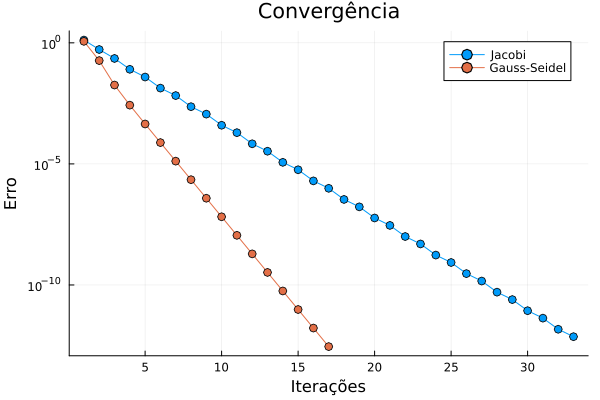

In [7]:
A = [15 9; 2 7]
b = [34, 17]

plotar_comparativo(A,b)


Solução Real :[0.3191489361702128, 0.40425531914893614]
Solução Aproximada Jacobi :[0.31914893617014073, 0.40425531914881263]
Solução Aproximada Gauss Seidel: [0.31914893617014073, 0.40425531914895774]


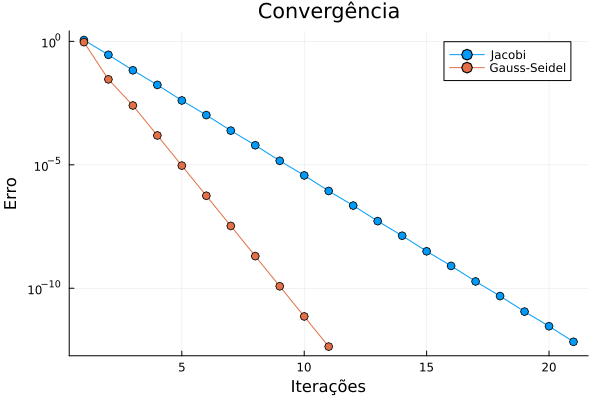

In [8]:
A = [10 2; 3 10]
b = [4, 5]

plotar_comparativo(A,b)

Solução Real :[3.7878281622911696, 1.7305489260143199, -1.2990453460620526]
Solução Aproximada Jacobi :[3.7878281622906815, 1.730548926013955, -1.2990453460624358]
Solução Aproximada Gauss Seidel: [3.787828162291648, 1.7305489260145164, -1.299045346062362]


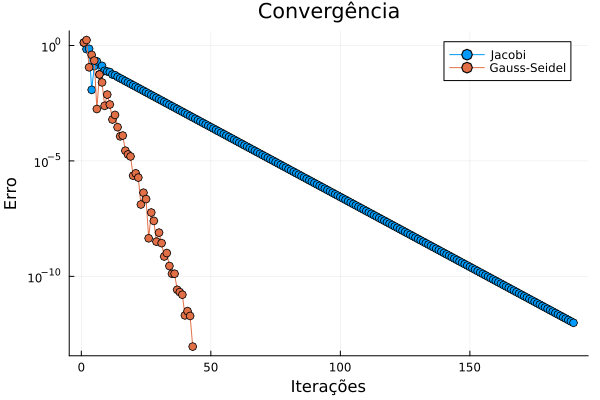

In [9]:
A = [15 9 8; 1 10 7; 21 4 35]
b = [62, 12, 41]

plotar_comparativo(A,b)


Solução Real :[2.8739649842320296, 0.19794628015721372, -0.6984511658976869]
Solução Aproximada Jacobi :[2.873964984232412, 0.19794628015744797, -0.6984511658973622]
Solução Aproximada Gauss Seidel: [2.873964984232148, 0.19794628015720284, -0.6984511658977108]


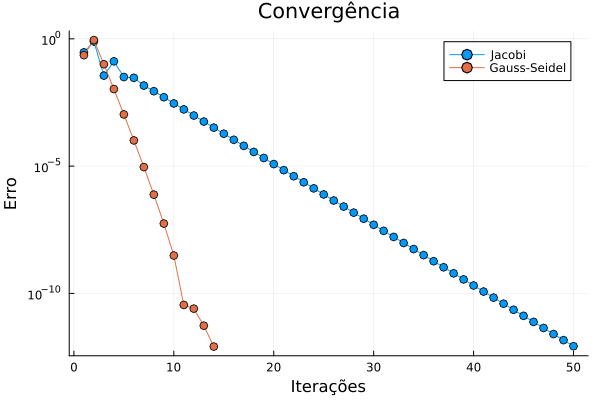

In [406]:
A = [42 16 17; 9 35 4; 13 22 54]
b = [112, 30, 4]

plotar_comparativo(A,b)

In [11]:
function plotar_comparativo_mod(A, b)
    x_j, arr1 = JacobiMethod(A, b, 10^(-12))
    x_gs, arr2 = GaussSeidelMethod(A, b, 10^(-12))

    println("Solução Real :", A\b)
    println("Solução Aproximada Jacobi :", x_j)
    println("Solução Aproximada Gauss Seidel: ", x_gs)
    
    eixo_1 = 1:length(arr1)
    eixo_2 = 1:length(arr2)

    plot(eixo_1, arr1, label= "Jacobi", marker= :o)
    plot!(eixo_2, arr2, label= "Gauss-Seidel", marker= :o)

    title!("Convergência")
    xlabel!("Iterações")
    ylabel!("Erro")

end

plotar_comparativo_mod (generic function with 1 method)

*Comentário:* Foram feitos testes com matrizes diagonal dominante e, em geral, podemos perceber que Gauss-Seidel converge mais rápido que Jacobi.

In [12]:
# Código gerando gráficos

(Comentários)

## Questão 1c: Matrizes maiores
Teste com matrizes maiores.  Estes métodos funcionam para matrizes do tipo `rand(m,m)`?

In [173]:
A= rand(5,5)
b= rand(5)


println("Solução Real: ", A\b)
JacobiMethod(A, b, 0.9, true) 
GaussSeidelMethod(A, b, 0.9, true)

Solução Real: [-1.449558930895933, -0.783229324615576, 1.4949422462804127, 0.9749579684046811, 0.29035985661636593]
Jacobi não convergiu.
Solução Aproximada Jacobi: [1.148400611474878e308, 8.239554346579117e307, 1.3498219353173752e308, 3.603685098249494e307, 5.708852497017098e307]
Histórico de erros: [6.2356429495319965, 28.552774343902534, 102.14555211589732, 423.37420699459165, 1666.4662478541218, 6618.896578533618, 26337.23032991927, 104568.61144060112, 415567.587231972, 1.651147431325322e6, 6.560355837346216e6, 2.6066552328677155e7, 1.0356951829123522e8, 4.1151218781440115e8, 1.6350580709973154e9, 6.4965604919377365e9, 2.581272918766521e10, 1.0256148789768222e11, 4.075066596180466e11, 1.6191426381563606e12, 6.433325219276588e12, 2.556147463170902e13, 1.0156318275111616e14, 4.0354010242235125e14, 1.60338234645678e15, 6.370705001547021e15, 2.5312666256420908e16, 1.0057459462522214e17, 3.9961215391349734e17, 1.5877754630833935e18, 6.308694308919103e18, 2.5066279715711066e19, 9.9595629

In [174]:
A= rand(30,30)
b= rand(30)


println("Solução Real: ", A\b)
JacobiMethod(A, b, 0.9, true) 
GaussSeidelMethod(A, b, 0.9, true)

Solução Real: [-0.7692407592831385, 0.7612841584511088, 0.7794751633409656, -1.8195321712276165, 0.28717407842183545, -0.15329182128742788, 0.7131323164208766, 0.29097024733248644, 0.3814283086494161, 1.095058046125992, -0.2855069213541709, -0.41706782845446694, -0.15136365814240646, -0.2701088635645659, -0.8644121725464637, 0.427731200412079, 0.42652966731914893, -0.12497013204360086, -0.23241010703586631, -0.059297392112853016, -0.5087446664016982, -0.05710719959760659, 0.18493196445291635, 0.22103218391386822, 0.4425241815934703, -0.7062136418011006, 0.6082520229499818, 1.0784258550754675, -0.10495818265089266, 0.12153039224855997]
Jacobi não convergiu.
Solução Aproximada Jacobi: [-3.7312487782232404e306, -7.819311886851014e306, -3.2191895608349234e306, -5.062078987231607e306, -9.548971416558242e306, -1.0396270847994323e307, -1.1950037864025089e307, -5.410699568342119e306, -4.6231781429685664e306, -3.97357455301239e306, -3.21004217802542e306, -5.3809614521720846e306, -Inf, -1.345583

In [175]:
A= rand(50, 50)
b= rand(50)


println("Solução Real: ", A\b)
JacobiMethod(A, b, 0.9, true) 
GaussSeidelMethod(A, b, 0.9, true)

Solução Real: [0.8266012188187568, 1.3014965392752142, -0.7629640792017293, -0.03788794195565305, 0.24126411925639585, 0.19437276683032, 0.12290950407187318, 0.3453479861014111, -0.641137220571918, -0.5597640118376044, 0.7810091573493373, -0.7375625165658352, 0.03299395551170388, -0.11802130915361338, -0.29003079525419556, 0.8326481872253041, -0.7256564049285383, 0.885011036984601, -0.5475731929171723, 0.7514367249139656, -0.6400391743632233, 0.07943667016787627, 0.33932684858327855, -0.4020064037024489, 0.7423544998178728, -1.0328097244537036, 0.07285570375892716, -0.2781002137073784, 0.2808133775810448, -0.9129415023287795, -0.3084053724894816, 0.0780387795492837, -0.9760956840338341, -0.08742420815700336, 0.23973851826112172, -0.026644234502395902, -0.24699543588611833, 0.3283927348126512, -0.010420455046641562, 0.32545366170597245, -0.8827661565372433, 1.1835118559672473, -0.2791190702849143, 0.9353043715215004, 0.017476338417428783, -0.09893728645832042, 0.13433351315440112, -0.28

*Comentário:* Em geral, os métodos não funcionam para matrizes `rand(m,m)`.

## Questão 1d: Matrizes maiores ainda!
Quão grande deve ser $k(m)$ para funcionar para 95\% das matrizes do tipo `randn(m,m)` + $ k(m) \cdot I_m$?  Quais velocidades de convergência você observa para este $k(m)$?

*Comentário:* Professor, a princípio, a ideia para saber se a matriz converge ou não foi: sabemos, como foi demonstrado em sala que $\left\|M_J\right\|_{p\rightarrow p} < 1$, então o método de Jacobi converge. Dessa forma, a primeira métrica utilizada para saber se converge ou não foi:

 $|a_{ii} + k(m)| > \sum|a_{ij}|$

 $|a_{ii}| + |k(m)| >= |a_{ii} + k(m)|$

 $\rightarrow  |k(m)| > \sum|a_{ij}| - |a_{ii}|$

 E, para cada tamanho de matriz eu estava achando $n$ $k(m)$ mínimos $ = \max (\sum|a_{ij}|) - |a_{ii}|$, o tamanho máximo que consegui fazer foi até $200$ com $n = 100.000$, e o que eu achei foi quase uma reta, mas k decaia conforme o tamanho aumentava. Porém, conversando com o senhor, o senhor disse que estava esperando algo em função de $\sqrt m$, e descobri que os $k$'s que eu estava achando não são o mínimo para que as matrizes convirjam. E acredito que o problema seja que eu não estou conseguindo o $k$ mínimo quando faço  $|a_{ii}| + |k(m)| >= |a_{ii} + k(m)|$.

 Portanto, alterei a lógica da minha função adicionando um parâmetro para retornar se convergiu ou não, se o método demorar mais de 1000 iterações para tentar a alcançar o erro proposto, assumo que não convergiu, se o erro retornou um NaN ou inf, assumo que não convergiu, caso contrário, convergiu. Dessa forma, agora consigo saber o k(m) necessário para convergir para 0.95 das matrizes de acordo com essa métrica em um while, em que começo com um $k(m) = \sqrt m$ e adiciono $0.2$ a cada iteração $k(m) = \sqrt m + t \times 0.2$. A razão disso foi que eu não sabia quão menores meus $k$'s poderiam ser, então sabendo que o senhor esperava algo em função de $\sqrt m$, testei algo partindo disso mas com avanços pequenos.

 Assim, achei o k mínimo dessa forma para cada tamanho de matriz de 1:100 e percebi que se aproximou bastante de $\sqrt m$. Dessa forma, invés de fazer uma regressão polinomial, pensei em fazer novamente pela pseudo inversa $\Phi^{\dagger} = (\Phi^T \Phi)^{-1}\Phi^T$, mas agora com uma coluna de 1's e uma coluna com $\sqrt m$ para tentar aprender o valor necessário para somar e ficar semelhante aos k's observados.

 $k(m) = 1.3400642516710848 + m \times 1.0321175676860332 $ é o final encontrado.

 Na questão 1e, explico um pouco melhor a ideia de que um bom parâmetro para saber se uma matriz converge ou não é se o maior autovalor em módulo da matriz é menor que 1. Dessa forma, fiz uma comparação entre o quantil 95 da norma infinito da matriz $M_J$ e quantil 95 do seu maior autovalor para n observações com o k_min já aplicado na diagonal. Percebemos que há uma grande diferença entre esses dois valores o que explica os grandes valores de k encontrados na primeira metodologia. 

- Encontrando os k's observando quando 95% das matrizes convergem:

In [80]:
data_k = Float64[]
max = 1000

for dim in 1:100
    p_conv = 0
    t = 0
    f(m,t) = sqrt(m) + 0.2000*t
    while p_conv < 0.9500
        
        aux = 0

        for i in 1:max
            A = randn(dim, dim) + f(dim,t) * Matrix(I, dim, dim)
            b = randn(dim)
            converge_J = JacobiMethod(A, b, 10^(-12), false, false, true)
            converge_GS  = GaussSeidelMethod(A, b, 10^(-12),false, false, true)

            if converge_J == true && converge_GS == true
                aux += 1
            end
        end

        p_conv = aux/max
        # println(p_conv)
        t += 1
    end
    print(dim)
    print(" ")
    print(f(dim,t))
    push!(data_k, f(dim,t))
    print(" ")
    print(p_conv)
    println(" ")

end

1 1.2 1.0 
2 2.414213562373095 0.957 
3 2.9320508075688774 0.95 
4 3.4000000000000004 0.964 
5 3.63606797749979 0.962 
6 3.8494897427831782 0.959 
7 4.045751311064591 0.954 
8 4.22842712474619 0.958 
9 4.4 0.959 
10 4.562277660168379 0.951 
11 4.9166247903553995 0.968 
12 4.864101615137755 0.955 
13 5.005551275463989 0.954 
14 5.141657386773941 0.954 
15 5.272983346207417 0.955 
16 5.6 0.975 
17 5.723105625617661 0.965 
18 5.842640687119285 0.983 
19 5.9588989435406745 0.963 
20 5.87213595499958 0.951 
21 5.98257569495584 0.954 
22 6.09041575982343 0.953 
23 6.395831523312719 0.969 
24 6.498979485566355 0.97 
25 6.4 0.95 
26 6.699019513592784 0.977 
27 6.596152422706632 0.959 
28 6.891502622129181 0.97 
29 6.985164807134504 0.96 
30 7.077225575051662 0.979 
31 6.967764362830022 0.954 
32 7.256854249492381 0.971 
33 7.344562646538028 0.978 
34 7.4309518948453 0.966 
35 7.516079783099617 0.97 
36 7.6 0.967 
37 7.68276253029822 0.972 
38 7.7644140029689765 0.95 
39 7.844997998398398 0.966

In [83]:
data_k

100-element Vector{Float64}:
  1.2
  2.414213562373095
  2.9320508075688774
  3.4000000000000004
  3.63606797749979
  3.8494897427831782
  4.045751311064591
  4.22842712474619
  4.4
  4.562277660168379
  ⋮
 11.191663046625438
 11.443650760992956
 11.295359714832658
 11.346794344808963
 11.397958971132711
 11.448857801796104
 11.499494936611665
 11.549874371066199
 11.6

- Encontrando o k pela norma da matriz:

In [ ]:
data_k_min = Float64[]

for dim in 2:100
    data = Float64[]
    println(dim)
    for i in 1:100000
        A = randn(dim,dim)
        diagonal = diag(A)
        A[diagind(A)] .= 0

        row_sums = sum(abs.(A), dims= 2)
        max_norm, row_idx = findmax(row_sums)
        k_min = max_norm - diagonal[row_idx[1]]
        push!(data, k_min)
    end
    k95 = quantile(data, 0.95)
    push!(data_k_min, k95)
end

2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100


In [49]:
data_k_min

99-element Vector{Float64}:
  3.077387436593082
  4.469123652613619
  5.772666159940893
  7.033298793324147
  8.24253033548823
  9.407577524698004
 10.5792760676091
 11.716098148089692
 12.864072814990024
 13.981461154402444
  ⋮
 92.54879238332137
 93.44965533747855
 94.34764341065379
 95.29748761493262
 96.17590541931507
 97.12617509305048
 98.02223598304239
 98.97698863769331
 99.82867585794975

In [50]:
eixo_x = 2:100

2:100

- Gráfico comparativo entre as metodologias:

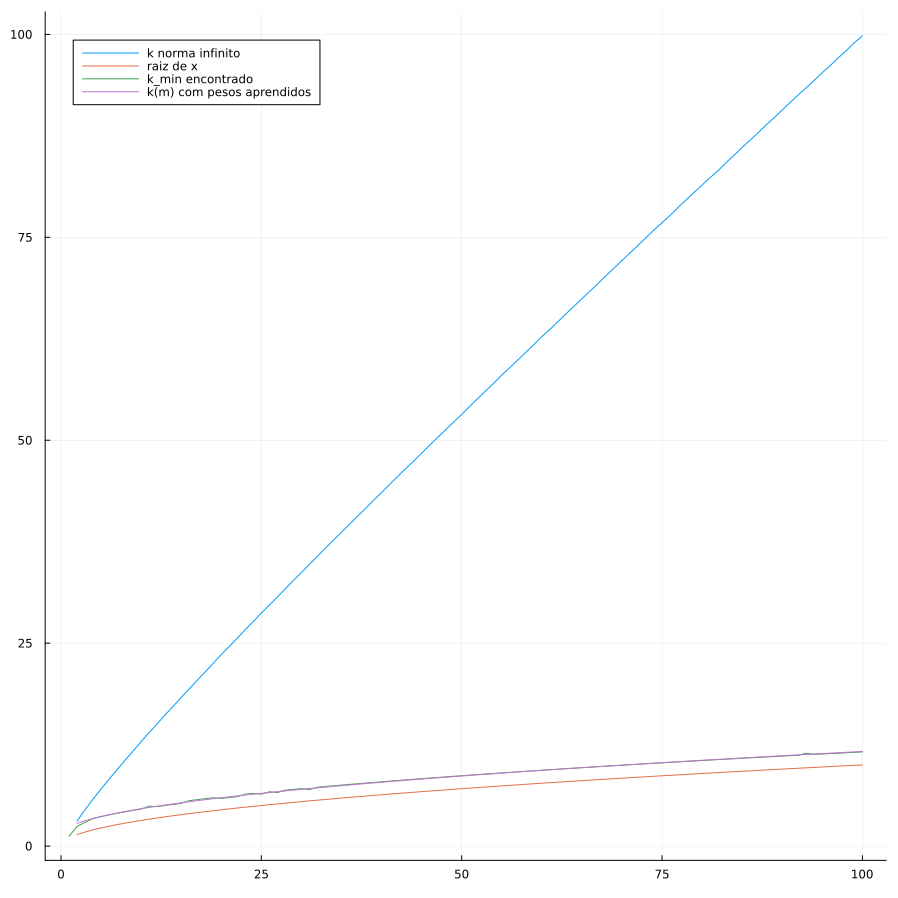

In [ ]:
plot(2:100, data_k_min, size= (900,900), label= "k norma infinito")
plot!(eixo_x, sqrt.(eixo_x) , label= "raiz de x")
plot!(1:100, data_k, label= "k_min encontrado")
plot!(eixo_x, 1.3400642516710848 .+ sqrt.(eixo_x) .* 1.0321175676860332, label= "k(m) com pesos aprendidos")

In [ ]:
function createPhi(vetor, n)
    Phi = zeros(size(vetor, 1), n+1)
    Phi[:,1] += ones(size(vetor, 1))
    for i in 2:n+1
        Phi[:,i] .+= sqrt.(vetor)
    end 
    return Phi
end

createPhi (generic function with 1 method)

In [324]:
Phi1 = createPhi([2:100;], 1)

99×2 Matrix{Float64}:
 1.0   1.41421
 1.0   1.73205
 1.0   2.0
 1.0   2.23607
 1.0   2.44949
 1.0   2.64575
 1.0   2.82843
 1.0   3.0
 1.0   3.16228
 1.0   3.31662
 ⋮    
 1.0   9.59166
 1.0   9.64365
 1.0   9.69536
 1.0   9.74679
 1.0   9.79796
 1.0   9.84886
 1.0   9.89949
 1.0   9.94987
 1.0  10.0

In [ ]:
function linear_regression_PI(Phi, target)
    PhiTPhi = transpose(Phi)*Phi
    pinv = inv(PhiTPhi)*transpose(Phi)
    w_learned = pinv*target
    return w_learned
end

linear_regression_PI (generic function with 1 method)

In [185]:
w_learned = linear_regression_PI(Phi1, data_k[2:100])

2-element Vector{Float64}:
 1.3400642516710848
 1.0321175676860332

In [554]:
f(m) = 1.3400642516710848 + sqrt(m) * 1.0321175676860332 

f (generic function with 1 method)

In [550]:
function test_comparativo(dim)
    data_norm = Float64[]
    data_eig = Float64[]

    for i in 1:10000
        A = randn(dim,dim) + f(dim)*Matrix(I,dim, dim)
    
        D = Diagonal(diag(A))
        L = tril(A, -1)
        U = triu(A, 1)

        T_J = D \ (L + U)

        row_sums = sum(abs.(T_J), dims= 2)
        max_norm, row_idx = findmax(row_sums)
        push!(data_norm, max_norm)

        r_J = maximum(abs, eigvals(Matrix(T_J)))
        push!(data_eig, r_J)

    end
    norm_95 = quantile(data_norm, 0.95)
    r_95 = quantile(data_eig, 0.95)

    print("Norma q-95: ")
    println(norm_95)
    print("Raio Espectral q-95: ")
    println(r_95)
end


test_comparativo (generic function with 1 method)

In [553]:
test_comparativo(4)

Norma q-95: 2.4972708299579947
Raio Espectral q-95: 0.8852594109818274


In [506]:
test_comparativo(10)

Norma q-95: 3.795118199165488
Raio Espectral q-95: 0.9168914627570662


In [505]:
test_comparativo(50)

Norma q-95: 7.4462284548321405
Raio Espectral q-95: 0.9750317196964158


In [497]:
test_comparativo(100)

Norma q-95: 10.232871867839627
Raio Espectral q-95: 0.9433158703177765


In [498]:
test_comparativo(500)

Norma q-95: 19.993306874937062
Raio Espectral q-95: 0.9662411354604006


In [499]:
test_comparativo(1000)

Norma q-95: 27.181837106145654
Raio Espectral q-95: 0.9695042597502427


In [501]:
test_comparativo(1050)

Norma q-95: 27.81236570536083
Raio Espectral q-95: 0.9666309006363605


In [622]:
function return_historic_it(dim)
    historic_j = Float64[]
    historic_gs = Float64[]


    for j in 1:1000
        it_j = 0
        it_gs = 0

        A = randn(dim, dim) + f(dim) * Matrix(I, dim, dim)
        b = randn(dim)

        conv_j  = JacobiMethod(A,b,1e-12, false, false, true)
        conv_gs  = GaussSeidelMethod(A,b,1e-12, false, false, true)

        if conv_j && conv_gs
            x_j, hist_j, it_j = JacobiMethod(A,b,1e-12, false, true)
            x_gs, hist_gs, it_gs = GaussSeidelMethod(A,b,1e-12, false, true)
        end

        if it_j > 0 && it_gs > 0
            push!(historic_j, it_j)
            push!(historic_gs, it_gs)
        end
    end

return historic_j, historic_gs
end

return_historic_it (generic function with 1 method)

- Histograma do número de iterações dos métodos:

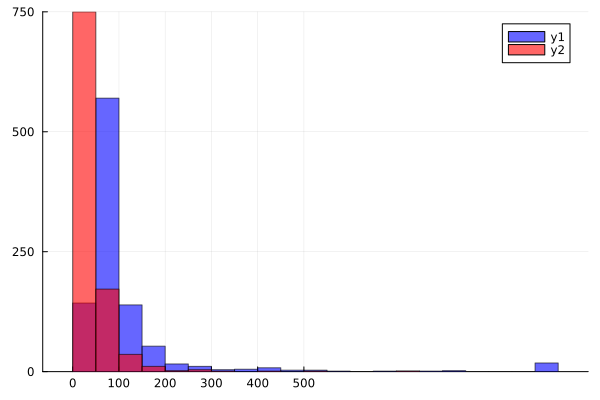

In [623]:
historic_j, historic_gs = return_historic_it(10)
histogram(historic_j, size= (600, 400), bins= 20, color = :blue, alpha = 0.6, xticks= 0:100:500)
histogram!(historic_gs, bins= 20, color = :red, alpha = 0.6, xticks= 0:100:500)

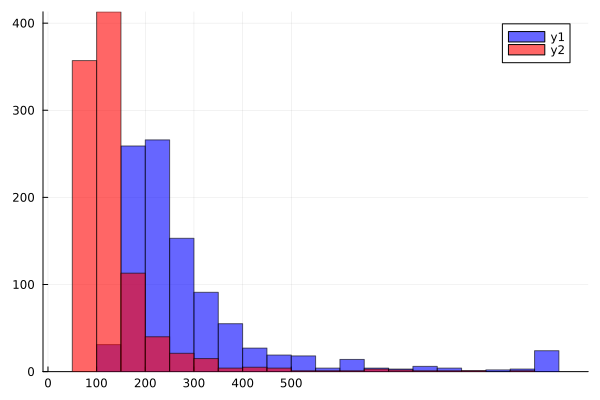

In [624]:
historic_j, historic_gs = return_historic_it(100)
histogram(historic_j, size= (600, 400), bins= 20, color = :blue, alpha = 0.6, xticks= 0:100:500)
histogram!(historic_gs, bins= 20, color = :red, alpha = 0.6, xticks= 0:100:500)

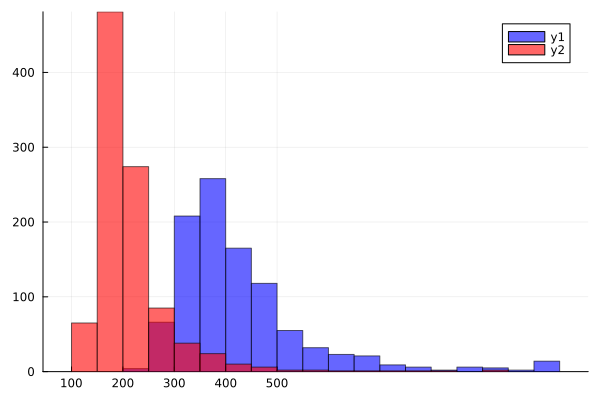

In [625]:
historic_j, historic_gs = return_historic_it(500)
histogram(historic_j, size= (600, 400), bins= 20, color = :blue, alpha = 0.6, xticks= 0:100:500)
histogram!(historic_gs, bins= 20, color = :red, alpha = 0.6, xticks= 0:100:500)

In [39]:
# Código (gerando possivelmente gráficos ou tabelas)

(Comentários)

## Questão 1e: Jacobi vs Gauss-Seidel
Encontre uma matriz $A$ $4 \times 4$ para a qual o método de Jacobi tenha melhor convergência que o método de Gauss-Seidel.

(Explique suas ideias, verifique abaixo)

*Comentários:* Como foi provado em sala, $e^{(k+1)} = M^{k}_J \times e^{(0)}$ e queremos que $e^{(k+1)} \rightarrow 0$. Queremos que nossas matrizes $M_J$ e $M_{GS}$ convirjam quando $k \rightarrow \infty$ . Podemos pensar na decomposição SVD dessas matrizes. Sabemos que, seja uma matriz $A = U \Sigma V^*$ , $A^k = U \Sigma^k V^*$, se $\Sigma^k \rightarrow 0$, então $A^k \rightarrow 0$. Portanto para que isso aconteça, os autovalores da nossa matriz precisam ser menores do que zero e para que $M_J$ convirja mais rápido que $M_{GS}$, o maior autovalor de $M_J$ precisa ser menor que o maior da $M_{GS}$.

In [330]:
dim = 4

for i in 1:10000 
    A = randn(dim, dim) + 5.78 * I 
    
    D = Diagonal(diag(A))
    L = tril(A, -1)
    U = triu(A, 1)

    T_J = D \ (L + U)
    T_GS = (D + L) \ U

    r_J = maximum(abs, eigvals(Matrix(T_J)))
    r_GS = maximum(abs, eigvals(Matrix(T_GS)))

    if r_J < r_GS 
        println("A = ", A)
        print("(Jacobi) = ")
        println(r_J)
        print("(Gauss-Seidel) = ")
        println(r_GS)
        break
    end
end


A = [4.793266565469686 -1.807483374852224 -1.7123419959776447 1.696313988976748; 1.3895309663926703 6.178401809373831 1.0274226456647388 0.034360633666321076; 1.5226679142747597 1.415628260198499 5.442642447490556 -2.7130686005331834; -1.1415059582071878 1.1400544468286287 2.2263251961468336 2.4117682175228197]
(Jacobi) = 0.8758393717540264
(Gauss-Seidel) = 1.0056619774775672


Solução Real :[0.4796879291066578, -0.03963105141509813, -0.27450112257127757, -0.2450855736983742]
Solução Aproximada Jacobi :[0.4796879291066948, -0.039631051414826535, -0.2745011225711484, -0.24508557369832434]
Solução Aproximada Gauss Seidel: [0.479687929106771, -0.03963105141474477, -0.27450112257142084, -0.24508557369847986]


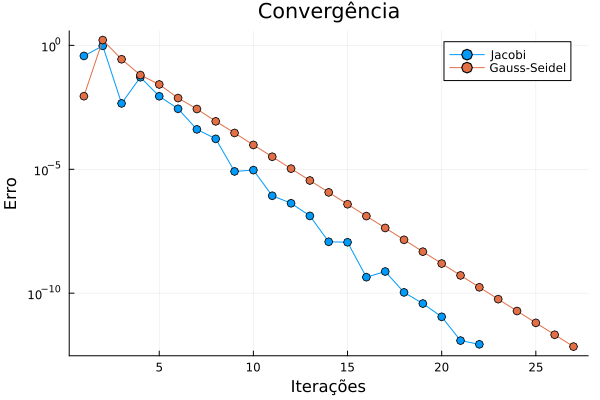

In [424]:
#Melhor matriz encontrada até o momento

A = [4.571493543551633 1.2936884214383129 0.5079548920865203 2.012431363288344; 
    1.1047725846900291 4.296368358413952 -0.410875767911238 -4.607158153656866; 
    0.08311985322957496 1.0469403584540433 5.0183555008347716 1.0669037631203093; 
    1.336639769865952 1.4146785630011784 -0.8458322601947313 7.308874646781852]

b = randn(4)

plotar_comparativo(A,b)

## Questão 1f: Perturbações
O que acontece se você somar uma matriz aleatória e pequena à matriz $A$ acima?  O que acontece se esta perturbação acontecer apenas fora da diagonal?

*Comentário:* Em geral, se adicionarmos uma matriz aleatória com valores entre 0 e 1 a nossa matriz o método Gauss-Seidel volta a convergir mais rápido.

Solução Real :[0.1134233158749827, -0.15677872279267616, 0.2230562732352995, 0.0016013335067083098]
Solução Aproximada Jacobi :[0.11342331587480033, -0.15677872279240007, 0.22305627323509414, 0.001601333506680347]
Solução Aproximada Gauss Seidel: [0.1134233158749905, -0.1567787227925638, 0.22305627323521587, 0.0016013335066798404]


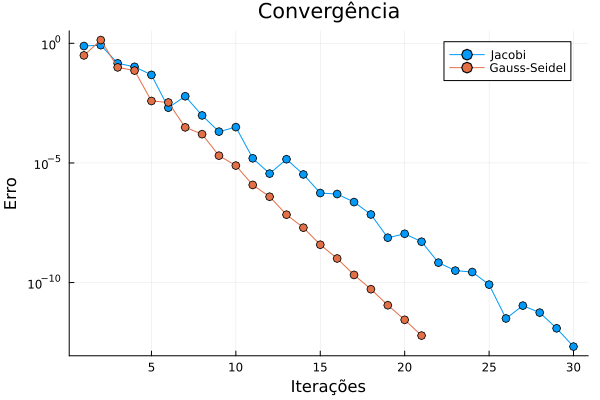

In [658]:
A = [4.571493543551633 1.2936884214383129 0.5079548920865203 2.012431363288344; 
    1.1047725846900291 4.296368358413952 -0.410875767911238 -4.607158153656866; 
    0.08311985322957496 1.0469403584540433 5.0183555008347716 1.0669037631203093; 
    1.336639769865952 1.4146785630011784 -0.8458322601947313 7.308874646781852]

ruido = rand(4,4)

b = randn(4)

plotar_comparativo(A + ruido,b)

*Comentário:* Em geral, se adicionarmos uma matriz aleatória apenas fora da diagonal, o método de Jacobi continua convergindo melhor.

Solução Real :[0.03747524165507857, 0.06431711824554896, 0.06255796796768417, 0.04585211889848517]
Solução Aproximada Jacobi :[0.03747524165521071, 0.06431711824540683, 0.06255796796773398, 0.04585211889853345]
Solução Aproximada Gauss Seidel: [0.03747524165483471, 0.06431711824473255, 0.06255796796805779, 0.04585211889874043]


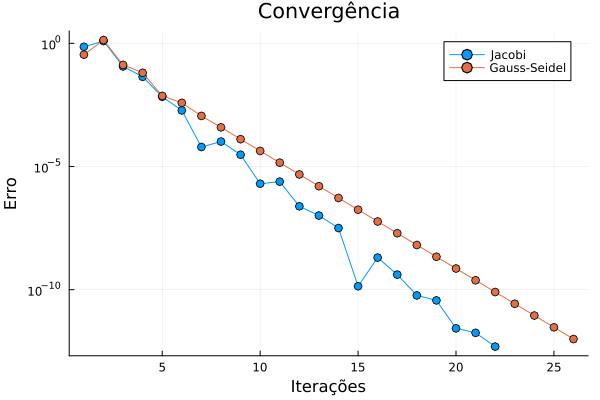

In [663]:
A = [4.571493543551633 1.2936884214383129 0.5079548920865203 2.012431363288344; 
    1.1047725846900291 4.296368358413952 -0.410875767911238 -4.607158153656866; 
    0.08311985322957496 1.0469403584540433 5.0183555008347716 1.0669037631203093; 
    1.336639769865952 1.4146785630011784 -0.8458322601947313 7.308874646781852]

ruido = ones(4,4) ./ 10
ruido[diagind(ruido)] .= 0
b = rand(4)

plotar_comparativo(A + ruido,b)

Solução Real :[0.05230381339057151, 0.09497586333111079, -0.03825717566829944, 0.038045342145856774]
Solução Aproximada Jacobi :[0.05230381339087031, 0.09497586333081895, -0.03825717566804672, 0.03804534214596529]
Solução Aproximada Gauss Seidel: [0.052303813390519364, 0.0949758633309623, -0.03825717566818814, 0.03804534214592001]


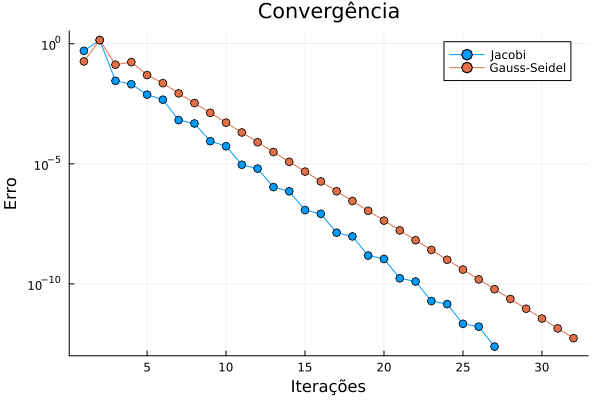

In [708]:
A = [4.571493543551633 1.2936884214383129 0.5079548920865203 2.012431363288344; 
    1.1047725846900291 4.296368358413952 -0.410875767911238 -4.607158153656866; 
    0.08311985322957496 1.0469403584540433 5.0183555008347716 1.0669037631203093; 
    1.336639769865952 1.4146785630011784 -0.8458322601947313 7.308874646781852]

ruido = rand(4,4) 
ruido[diagind(ruido)] .= 0
b = rand(4)

plotar_comparativo(A + ruido,b)

(Comentários)